In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, precision_recall_curve, classification_report
)

In [2]:
df = pd.read_csv("D:\\Github\\Artificial-Intelligence-Labs\\Diabetes Diagnostic Tool\\data\\raw\\diabetes.csv")   # Kaggle file name is often diabetes.csv
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [6]:
df.shape
df.describe()
df.isna().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
zero_cols=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
(df[zero_cols] == 0).sum().sort_values(ascending=False)


Insulin          374
SkinThickness    227
BloodPressure     35
BMI               11
Glucose            5
dtype: int64

In [16]:
df['Outcome'].value_counts()
df['Outcome'].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

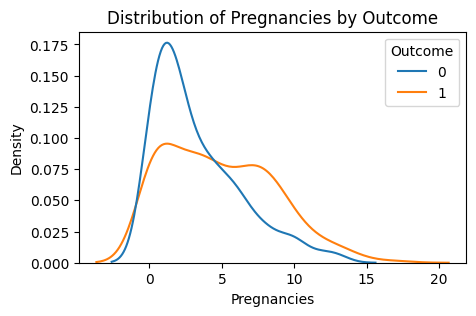

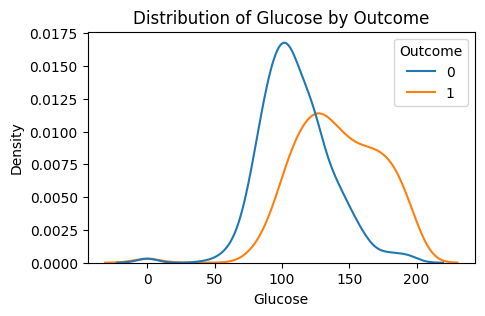

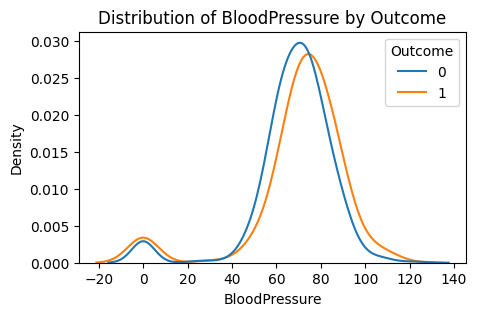

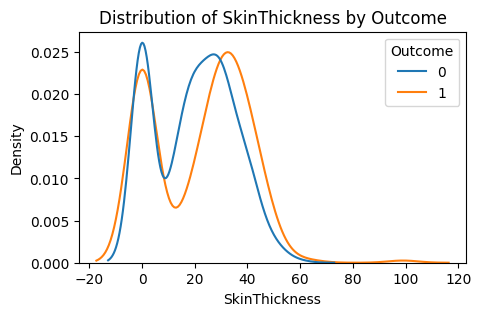

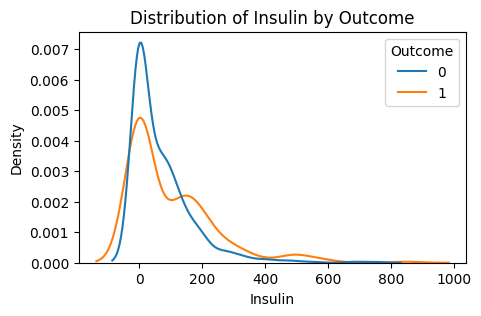

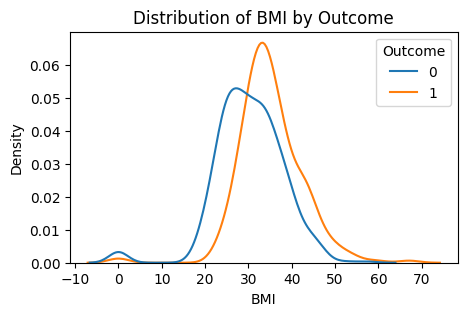

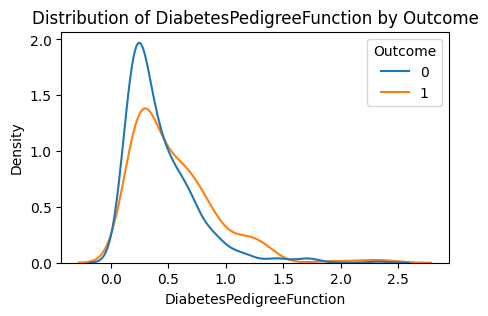

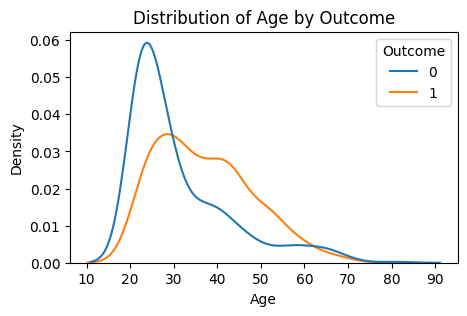

In [20]:
for col in df.columns.drop('Outcome'):
    plt.figure(figsize=(5,3))
    sns.kdeplot(data=df,x=col,hue='Outcome',common_norm=False)
    plt.title(f'Distribution of {col} by Outcome')
    plt.show()

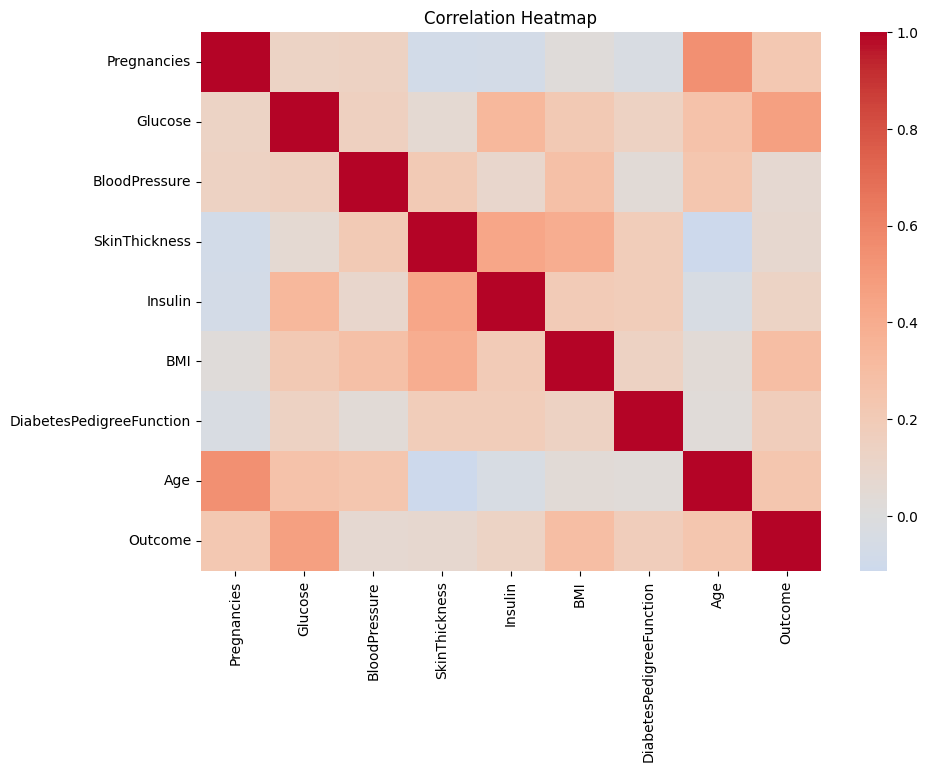

In [19]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm',center=0)
plt.title('Correlation Heatmap')
plt.show()

### **Train/Val/Test Split**

In [21]:
X=df.drop(columns=['Outcome'])
y=df['Outcome'].astype(int)
X_train, X_temp, y_train, y_temp=train_test_split(
    X,y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test=train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

### **Preprocessing + Model Traning (Pipline)**

In [22]:
X_train2=X_train.copy()
X_val2=X_val.copy()
X_test2=X_test.copy()

for c in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
    X_train2[c]=X_train2[c].replace(0,np.nan)
    X_val2[c]=X_val2[c].replace(0,np.nan)
    X_test2[c]=X_test2[c].replace(0,np.nan)

pipe = Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="median")),
    ("scaler",StandardScaler()),
    ("lr",LogisticRegression(max_iter=2000,solver="liblinear"))
])


### **Hyperparameter tuning**

In [23]:
param_grid={"lr__C": [0.01, 0.1, 1, 10, 100]}
grid=GridSearchCV(
    pipe,param_grid=param_grid,
    scoring="f1", cv=5, n_jobs=-1
)
grid.fit(X_train2,y_train)

best_model=grid.best_estimator_
print("Best C:",grid.best_params_)


Best C: {'lr__C': 0.1}


### **Threshold Tuning + Evalution**

In [24]:
val_proba=best_model.predict_proba(X_val2)[:, 1]

prec,rec,thr=precision_recall_curve(y_val,val_proba)

f1_scores=2*(prec[:-1]*rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
best_idx=np.argmax(f1_scores)
best_threshold=thr[best_idx]
print("Chosen threshold:",best_threshold)
print("Val Precision/Recall/F1:",
      prec[best_idx], rec[best_idx],f1_scores[best_idx])


Chosen threshold: 0.24979594189391496
Val Precision/Recall/F1: 0.5428571428571428 0.95 0.690909090908628


### **Evaluation on testing set**

{'threshold': 0.5, 'accuracy': 0.7586206896551724, 'precision': 0.7241379310344828, 'recall': 0.5121951219512195, 'f1': 0.6, 'cm': array([[67,  8],
       [20, 21]])}
{'threshold': 0.24979594189391496, 'accuracy': 0.7672413793103449, 'precision': 0.625, 'recall': 0.8536585365853658, 'f1': 0.7216494845360825, 'cm': array([[54, 21],
       [ 6, 35]])}


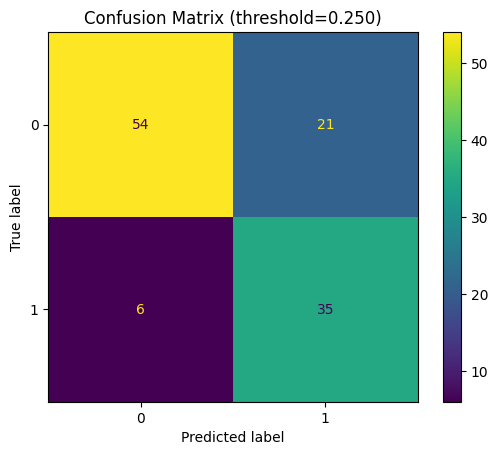

              precision    recall  f1-score   support

           0       0.90      0.72      0.80        75
           1       0.62      0.85      0.72        41

    accuracy                           0.77       116
   macro avg       0.76      0.79      0.76       116
weighted avg       0.80      0.77      0.77       116



In [25]:
test_proba=best_model.predict_proba(X_test2)[:, 1]

def evaluate_at_threshold(y_true, proba, t):
    y_pred=(proba >=t).astype(int)
    return {
        "threshold": t,
        "accuracy": accuracy_score(y_true,y_pred),
        "precision": precision_score(y_true,y_pred,zero_division=0),
        "recall": recall_score(y_true,y_pred,zero_division=0),
        "f1": f1_score(y_true,y_pred,zero_division=0),
        "cm": confusion_matrix(y_true,y_pred)
    }

res_05=evaluate_at_threshold(y_test,test_proba, 0.5)
res_t=evaluate_at_threshold(y_test,test_proba,float(best_threshold))

print(res_05)
print(res_t)

ConfusionMatrixDisplay(res_t["cm"]).plot()
plt.title(f"Confusion Matrix (threshold={best_threshold:.3f})")
plt.show()

print(classification_report(y_test, (test_proba >= best_threshold).astype(int)))


### **ROC + AUC(AUC uses probabilties, not a threshold)**

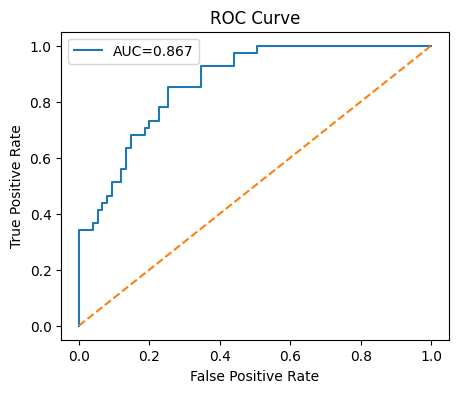

In [26]:
fpr,tpr, _ =roc_curve(y_test, test_proba)
auc=roc_auc_score(y_test, test_proba)

plt.figure(figsize=(5,4))
plt.plot(fpr,tpr,label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


### **Saving Model**

In [27]:
import joblib

artifact = {
    "model": best_model,
    "threshold": float(best_threshold),
    "feature_names": list(X.columns)
}
joblib.dump(artifact, "D:\\Github\\Artificial-Intelligence-Labs\\Diabetes Diagnostic Tool\\model\\diabetes_classification_model.pkl")


['D:\\Github\\Artificial-Intelligence-Labs\\Diabetes Diagnostic Tool\\model\\diabetes_classification_model.pkl']